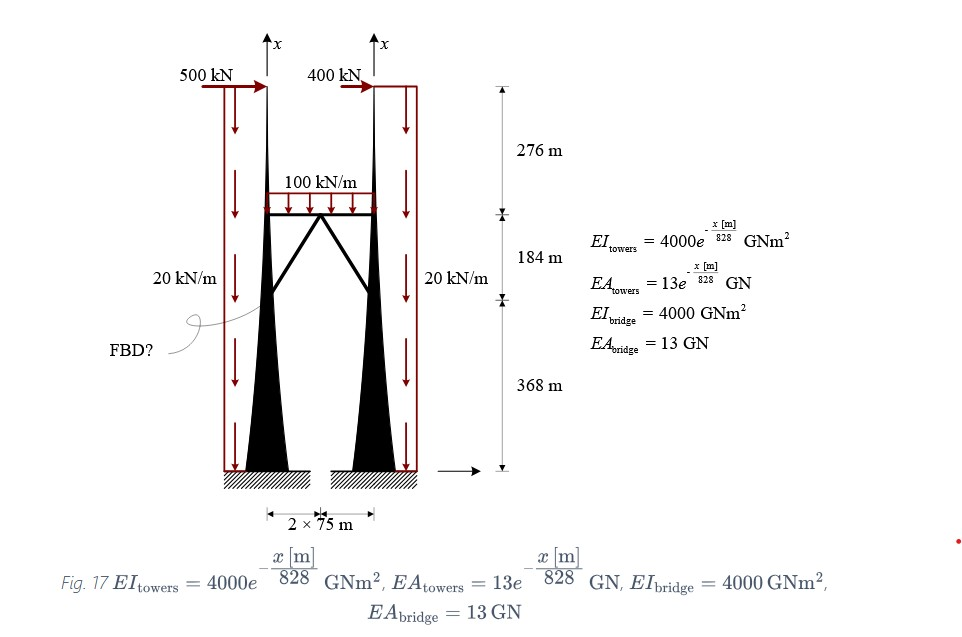

In [127]:
from IPython.display import Image, display
display(Image(filename='Screenshot 2026-04-17 100516.jpg'))

In [128]:
import numpy as np
import matrixmethod as mm
import matplotlib.pyplot as plt
import pandas as pd

%config InlineBackend.figure_formats = ['svg']
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [129]:
mm.Node.clear()
mm.Element.clear()


GN_to_kN = 1e6
GNm2_to_kNm2 = 1e6

def EI_tower(x):
    return 4000.0 * np.exp(-x / 828.0) * GNm2_to_kNm2

def EA_tower(x):
    return 13.0 * np.exp(-x / 828.0) * GN_to_kN

EI_bridge = 4000.0 * GNm2_to_kNm2
EA_bridge = 13.0 * GN_to_kN

# loads
q_tower = -20.0     # distributed load on towers
q_bridge = 100.0    # distributed load on bridge

Fx_left_top = 500
Fx_right_top = 400

# q_tower = 0 # - CORRECT
# q_bridge = 0 # + CORRECT

# Fx_left_top = 0 # + CORRECT
# Fx_right_top = 0 # + CORRECT


# geometry
tower_height = 828.0

y_left = 0.0
y_right = 150.0
y_mid = 75.0

x_base = 0.0
x_low = 368.0
x_bridge = 552.0
x_top = 828.0

In [130]:
# coordinates: x vertical, z horizontal
n1 = mm.Node(0.0,   0.0)
n2 = mm.Node(368.0, 0.0)
n3 = mm.Node(552.0, 0.0)
n4 = mm.Node(828.0, 0.0)

n5 = mm.Node(0.0,   150.0)
n6 = mm.Node(368.0, 150.0)
n7 = mm.Node(552.0, 150.0)
n8 = mm.Node(828.0, 150.0)

n9  = mm.Node(552.0, 75.0)

nodes = [n1,n2,n3,n4,n5,n6,n7,n8,n9]
elements = []

def make_element(ni, nj, EA, EI):
    e = mm.Element(ni, nj)
    e.set_section({"EA": EA, "EI": EI})
    elements.append(e)
    return e

# towers
tower_node_pairs = [(n1,n2), (n2,n3), (n3,n4), (n5,n6), (n6,n7), (n7,n8)]

for ni, nj in tower_node_pairs:
    xm = 0.5 * (ni.x + nj.x)
    e = make_element(ni, nj, EA_tower(xm), EI_tower(xm))
    e.add_distributed_load([q_tower, 0.0])   # vertical load along tower local x

# bridge deck
e37 = make_element(n3, n9, EA_bridge, EI_bridge)
e97 = make_element(n9, n7, EA_bridge, EI_bridge)

e37.add_distributed_load([0.0, q_bridge])    # vertical downward on horizontal beam
e97.add_distributed_load([0.0, q_bridge])

# bracing
make_element(n2, n9,  EA_bridge, EI_bridge)
make_element(n6, n9,  EA_bridge, EI_bridge)

# point loads at top, horizontal to the right = +z direction
n4.add_load(np.array([0.0, Fx_left_top, 0.0]))
n8.add_load(np.array([0.0, Fx_right_top, 0.0]))

# assemble global stiffness and load vector
K = np.zeros((mm.Node.ndof, mm.Node.ndof))
F = np.zeros(mm.Node.ndof)

for node in nodes:
    F[node.dofs] += node.p

for e in elements:
    edofs = e.global_dofs()
    K[np.ix_(edofs, edofs)] += e.stiffness()

# boundary conditions
con = mm.Constrainer()
con.fix_node(n1)
con.fix_node(n5)

Kff, Ff = con.constrain(K, F)
u_free = np.linalg.solve(Kff, Ff)
u = con.full_disp(u_free)

# displacement table
disp = []
for i, node in enumerate(nodes, start=1):
    ux, uz, phi = u[node.dofs]
    disp.append([i, node.x, node.z, ux, uz, phi])

disp_df = pd.DataFrame(
    disp,
    columns=["Node", "x [m]", "z [m]", "u_x [m]", "u_z [m]", "phi [rad]"]
)

display(disp_df)

# reactions
reaction_rows = []

supports = [n1, n5]

for node in supports:

    node_id = nodes.index(node) + 1

    reaction_rows.append([
        node_id,
        node.x,
        node.z,
        reactions[con.cons_dofs.index(node.dofs[0])],   # u_x
        reactions[con.cons_dofs.index(node.dofs[1])],   # u_z
        reactions[con.cons_dofs.index(node.dofs[2])]    # phi
    ])

reaction_df = pd.DataFrame(
    reaction_rows,
    columns=[
        "Support node",
        "x [m]",
        "z [m]",
        "Vertical reaction Rx [kN]",
        "Horizontal reaction Rz [kN]",
        "Support moment M [kNm]"
    ]
)

display(
    reaction_df.style
    .hide(axis="index")
    .format({
        "Vertical reaction Rx [kN]": "{:.2f}",
        "Horizontal reaction Rz [kN]": "{:.2f}",
        "Support moment M [kNm]": "{:.2f}"
    })
)

,Node,x [m],z [m],u_x [m],u_z [m],phi [rad]
0,1,0.0,0.0,0.000000,0.000000,0.000000
1,2,368.0,0.0,-0.594696,0.729501,-0.004548
2,3,552.0,0.0,-0.786905,1.477286,-0.003380
3,4,828.0,0.0,-0.921736,4.425783,-0.014335
4,5,0.0,150.0,0.000000,0.000000,0.000000
5,6,368.0,150.0,-0.846253,1.408170,-0.000728
6,7,552.0,150.0,-1.101685,1.481591,-0.001950
7,8,828.0,150.0,-1.236515,3.632382,-0.010714
8,9,552.0,75.0,-0.953196,1.474872,-0.001833


Support node,x [m],z [m],Vertical reaction Rx [kN],Horizontal reaction Rz [kN],Support moment M [kNm]
1,0.000000,0.000000,20502.12,82.74,24358.39
5,0.000000,150.000000,27617.88,-982.74,187158.87


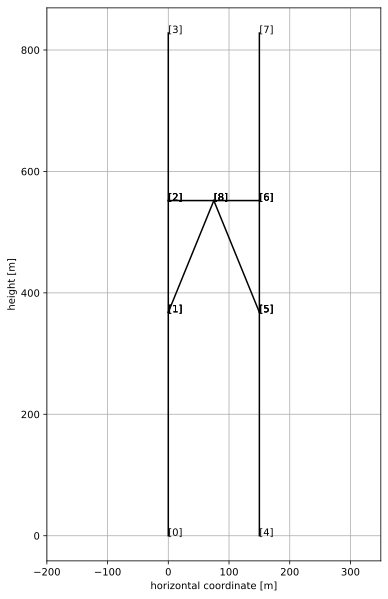

In [131]:
# Numbered structure
plt.figure(figsize=(6,10))

for i, e in enumerate(elements, start=1):
    X0 = e.nodes[0].x
    Z0 = e.nodes[0].z
    X1 = e.nodes[1].x
    Z1 = e.nodes[1].z

    plt.plot([Z0, Z1], [X0, X1], 'k-')

    plt.text(Z0, X0, f'[{e.nodes[0].dofs[0]//3}]')
    plt.text(Z1, X1, f'[{e.nodes[1].dofs[0]//3}]')

plt.xlabel("horizontal coordinate [m]")
plt.ylabel("height [m]")
plt.axis('equal')
plt.grid()
plt.show()

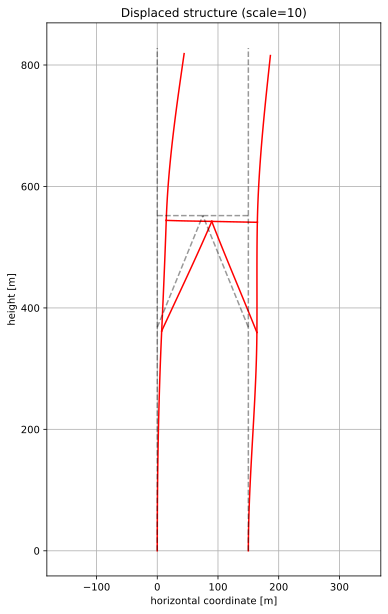

In [132]:
plt.figure(figsize=(6,10))

scale = 10

for e in elements:

    ue = u[e.global_dofs()]

    x_local = np.linspace(0, e.L, 40)
    u_axial, w = e.full_displacement(ue, num_points=40)

    coords_local = np.vstack((x_local + scale*u_axial,
                              scale*w))

    coords_global = e.Tt[:2,:2] @ coords_local

    X = coords_global[0,:] + e.nodes[0].x
    Z = coords_global[1,:] + e.nodes[0].z

    # swap axes here
    plt.plot(Z, X, 'r')

# undeformed structure
for e in elements:
    plt.plot(
        [e.nodes[0].z, e.nodes[1].z],
        [e.nodes[0].x, e.nodes[1].x],
        'k--', alpha=0.4
    )

plt.xlabel("horizontal coordinate [m]")
plt.ylabel("height [m]")
plt.title(f"Displaced structure (scale={scale})")
plt.axis('equal')
plt.grid()
plt.show()

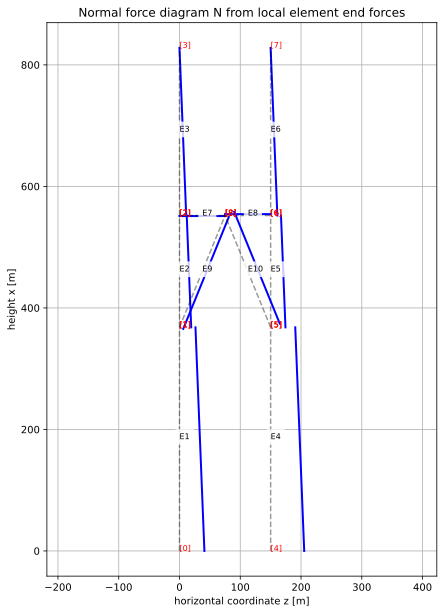

Node,Connected to node,Element,Normal force N
0,1,1,20502.12
1,0,1,13142.12
1,2,2,9631.59
1,8,9,3312.89
2,1,2,5951.59
2,3,3,5520.00
2,8,7,418.36
3,2,3,0.00
4,5,4,27617.88
5,4,4,20257.88


In [133]:
plt.figure(figsize=(7, 10))

scale_N = 0.002
node_force_rows = []

for i, e in enumerate(elements, start=1):

    ue_global = u[e.global_dofs()]
    ue_local = e.T @ ue_global

    k_local = e.T @ e.stiffness() @ e.Tt

    qx, qz = e.q
    L = e.L
    p_local = np.array([
        0.5*qx*L,
        0.5*qz*L,
        -qz*L**2/12,
        0.5*qx*L,
        0.5*qz*L,
        qz*L**2/12
    ])

    f_local = k_local @ ue_local - p_local

    N1 = f_local[0]
    N2 = -f_local[3]

    node_i = e.nodes[0].dofs[0] // 3
    node_j = e.nodes[1].dofs[0] // 3

    node_force_rows.append([node_i, node_j, i, "start", N1])
    node_force_rows.append([node_j, node_i, i, "end", N2])

    x_local = np.array([0.0, e.L])
    N = np.array([N1, N2])

    diagram_local = np.vstack((x_local, scale_N * N))
    diagram_global = e.Tt[:2, :2] @ diagram_local

    X = diagram_global[0, :] + e.nodes[0].x
    Z = diagram_global[1, :] + e.nodes[0].z

    plt.plot(Z, X, 'b', linewidth=2)

    plt.plot(
        [e.nodes[0].z, e.nodes[1].z],
        [e.nodes[0].x, e.nodes[1].x],
        'k--',
        alpha=0.4
    )

    Zm = 0.5 * (e.nodes[0].z + e.nodes[1].z)
    Xm = 0.5 * (e.nodes[0].x + e.nodes[1].x)

    plt.text(Zm, Xm, f"E{i}", fontsize=8,
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

    plt.text(e.nodes[0].z, e.nodes[0].x, f"[{node_i}]",
             fontsize=8, color="red")

    plt.text(e.nodes[1].z, e.nodes[1].x, f"[{node_j}]",
             fontsize=8, color="red")

plt.xlabel("horizontal coordinate z [m]")
plt.ylabel("height x [m]")
plt.title("Normal force diagram N from local element end forces")
plt.axis("equal")
plt.grid()
plt.show()


node_force_df = pd.DataFrame(
    node_force_rows,
    columns=["Node", "Connected to node", "Element", "Element side", "Normal force N"]
)

node_force_df["Normal force N"] = node_force_df["Normal force N"].round(2)

table = (
    node_force_df[["Node", "Connected to node", "Element", "Normal force N"]]
    .sort_values(["Node", "Connected to node"])
    .reset_index(drop=True)
)

display(
    table.style
    .hide(axis="index")
    .format({"Normal force N": "{:.2f}"})
)

Node,Element,Connected to node,Axial force N on node,Shear force V on node,Moment on node
1,1,0,13142.12,82.74,54804.96
1,2,2,-9631.59,81.64,7057.62
1,9,8,-3312.89,1172.85,-61862.58


Quantity,Residual
ΣFx,-1.305125e-10
ΣFz,-1.546141e-10
ΣM,-1.164153e-10


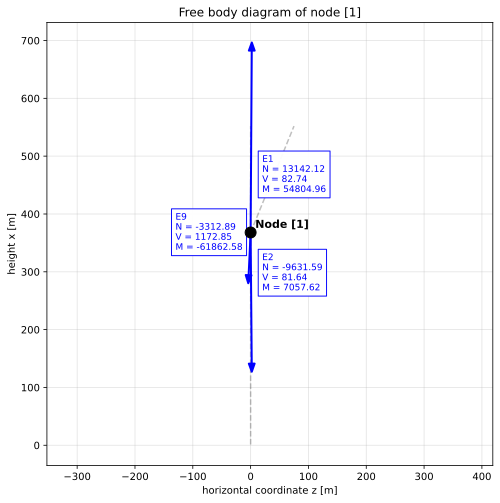

In [134]:
# Free body diagram for Node 1
target_node = n2
target_node_number = target_node.dofs[0] // 3

plt.figure(figsize=(8, 8))

node_force_rows = []

connected_elements = [
    (i, e) for i, e in enumerate(elements, start=1)
    if target_node in e.nodes
]

# Internal node -> only element actions should appear
sum_force = np.zeros(3)
sum_moment = 0.0

force_scale = 0.025

plt.scatter(target_node.z, target_node.x, s=120, color="black", zorder=10)

plt.text(
    target_node.z + 8,
    target_node.x + 8,
    f"Node [{target_node_number}]",
    fontsize=11,
    weight="bold"
)

# manual label offsets to avoid overlap
label_offsets = {
    1: (20, 70),
    2: (20, -100),
    9: (-130, -30)
}

for element_number, e in connected_elements:

    ue_global = u[e.global_dofs()]
    ue_local = e.T @ ue_global

    k_local = e.T @ e.stiffness() @ e.Tt

    qx, qz = e.q
    L = e.L

    p_local = np.array([
        0.5*qx*L,
        0.5*qz*L,
        -qz*L**2/12,
        0.5*qx*L,
        0.5*qz*L,
        qz*L**2/12
    ])

    f_local = k_local @ ue_local - p_local

    if target_node == e.nodes[0]:
        local_end_force = f_local[0:3]
        other_node = e.nodes[1]
    else:
        local_end_force = f_local[3:6]
        other_node = e.nodes[0]

    # force exerted by element on node
    local_force_on_node = -local_end_force

    global_force_on_node = e.Tt @ np.array([
        local_force_on_node[0],
        local_force_on_node[1],
        local_force_on_node[2],
        0.0,
        0.0,
        0.0
    ])

    Fx = global_force_on_node[0]
    Fz = global_force_on_node[1]
    M  = global_force_on_node[2]

    sum_force += np.array([Fx, Fz, 0.0])
    sum_moment += M

    node_force_rows.append([
        target_node_number,
        element_number,
        other_node.dofs[0] // 3,
        local_force_on_node[0],
        local_force_on_node[1],
        M
    ])

    # connected member (faded)
    plt.plot(
        [target_node.z, other_node.z],
        [target_node.x, other_node.x],
        "k--",
        alpha=0.25
    )

    # force arrow
    dx_arrow = force_scale * Fz
    dy_arrow = force_scale * Fx

    plt.arrow(
        target_node.z,
        target_node.x,
        dx_arrow,
        dy_arrow,
        head_width=10,
        head_length=14,
        linewidth=2,
        color="blue",
        length_includes_head=True,
        zorder=6
    )

    dz_text, dx_text = label_offsets.get(
        element_number,
        (15, 15)
    )

    plt.text(
        target_node.z + dz_text,
        target_node.x + dx_text,
        f"E{element_number}\n"
        f"N = {local_force_on_node[0]:.2f}\n"
        f"V = {local_force_on_node[1]:.2f}\n"
        f"M = {M:.2f}",
        fontsize=9,
        color="blue",
        bbox=dict(
            facecolor="white",
            alpha=0.95,
            edgecolor="blue"
        )
    )

# force table
fbd_df = pd.DataFrame(
    node_force_rows,
    columns=[
        "Node",
        "Element",
        "Connected to node",
        "Axial force N on node",
        "Shear force V on node",
        "Moment on node"
    ]
)

display(
    fbd_df.style
    .hide(axis="index")
    .format({
        "Axial force N on node": "{:.2f}",
        "Shear force V on node": "{:.2f}",
        "Moment on node": "{:.2f}"
    })
)

# equilibrium check
equilibrium_df = pd.DataFrame(
    {
        "Quantity": ["ΣFx", "ΣFz", "ΣM"],
        "Residual": [
            sum_force[0],
            sum_force[1],
            sum_moment
        ]
    }
)

display(
    equilibrium_df.style
    .hide(axis="index")
    .format({"Residual": "{:.6e}"})
)

plt.xlabel("horizontal coordinate z [m]")
plt.ylabel("height x [m]")
plt.title(
    f"Free body diagram of node [{target_node_number}]"
)

plt.xlim(
    target_node.z - 180,
    target_node.z + 180
)

plt.ylim(
    target_node.x - 220,
    target_node.x + 220
)

plt.axis("equal")
plt.grid(alpha=0.35)
plt.show()

Force,Fx vertical,Fz horizontal,Moment
Support node 0,20502.12,82.74,24358.39
Support node 4,27617.88,-982.74,187158.87
Distributed load E1,-7360.00,0.00,0.00
Distributed load E2,-3680.00,0.00,0.00
Distributed load E3,-5520.00,0.00,0.00
Distributed load E4,-7360.00,0.00,0.00
Distributed load E5,-3680.00,0.00,0.00
Distributed load E6,-5520.00,0.00,0.00
Distributed load E7,-7500.00,0.00,0.00
Distributed load E8,-7500.00,0.00,0.00


Quantity,Residual
ΣFx,-1.091394e-10
ΣFz,-2.753495e-10
ΣM support only,2.115173e+05


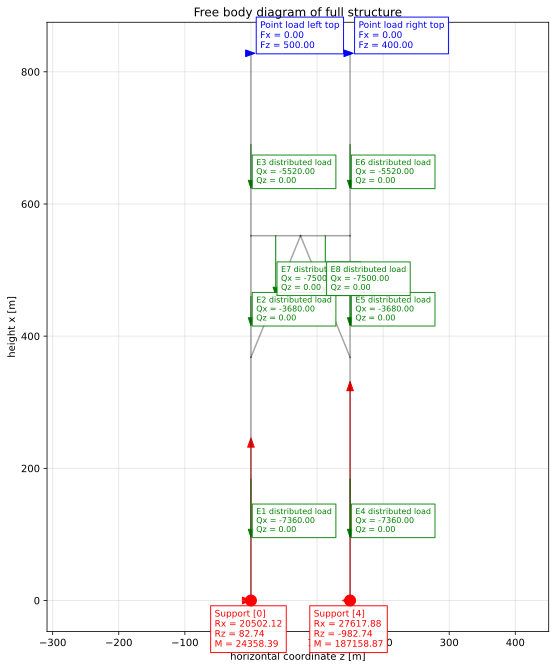

In [135]:
# Full-structure free body diagram

plt.figure(figsize=(9, 11))

force_scale = 0.012
moment_scale = 0.00005

force_rows = []

# undeformed structure
for e in elements:
    plt.plot(
        [e.nodes[0].z, e.nodes[1].z],
        [e.nodes[0].x, e.nodes[1].x],
        "k-",
        alpha=0.35
    )

# support reactions
reaction_dict = {}

for dof, R in zip(con.cons_dofs, reactions):
    reaction_dict[dof] = R

for node in [n1, n5]:
    Rx = reaction_dict.get(node.dofs[0], 0.0)   # vertical/global x
    Rz = reaction_dict.get(node.dofs[1], 0.0)   # horizontal/global z
    M  = reaction_dict.get(node.dofs[2], 0.0)

    plt.scatter(node.z, node.x, s=120, color="red", zorder=5)

    if abs(Rx) > 1e-9:
        plt.arrow(
            node.z, node.x,
            0,
            force_scale * Rx,
            head_width=10,
            head_length=14,
            color="red",
            length_includes_head=True
        )

    if abs(Rz) > 1e-9:
        plt.arrow(
            node.z, node.x,
            force_scale * Rz,
            0,
            head_width=10,
            head_length=14,
            color="red",
            length_includes_head=True
        )

    plt.text(
        node.z - 55,
        node.x - 70,
        f"Support [{node.dofs[0]//3}]\n"
        f"Rx = {Rx:.2f}\n"
        f"Rz = {Rz:.2f}\n"
        f"M = {M:.2f}",
        fontsize=9,
        color="red",
        bbox=dict(facecolor="white", alpha=0.95, edgecolor="red")
    )

    force_rows.append([f"Support node {node.dofs[0]//3}", Rx, Rz, M])

# distributed loads shown as resultants per element
for i, e in enumerate(elements, start=1):

    qx, qz = e.q

    if abs(qx) < 1e-12 and abs(qz) < 1e-12:
        continue

    L = e.L

    q_global = e.Tt[:2, :2] @ np.array([qx, qz])
    Qx = q_global[0] * L
    Qz = q_global[1] * L

    Xm = 0.5 * (e.nodes[0].x + e.nodes[1].x)
    Zm = 0.5 * (e.nodes[0].z + e.nodes[1].z)

    plt.arrow(
        Zm,
        Xm,
        force_scale * Qz,
        force_scale * Qx,
        head_width=8,
        head_length=12,
        color="green",
        length_includes_head=True
    )

    plt.text(
        Zm + force_scale * Qz + 8,
        Xm + force_scale * Qx + 8,
        f"E{i} distributed load\n"
        f"Qx = {Qx:.2f}\n"
        f"Qz = {Qz:.2f}",
        fontsize=8,
        color="green",
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="green")
    )

    force_rows.append([f"Distributed load E{i}", Qx, Qz, 0.0])

# point loads at tower tops
point_loads = [
    ("Point load left top", n4, 0.0, Fx_left_top, 0.0),
    ("Point load right top", n8, 0.0, Fx_right_top, 0.0)
]

for label, node, Fx, Fz, M in point_loads:

    plt.arrow(
        node.z,
        node.x,
        force_scale * Fz,
        force_scale * Fx,
        head_width=10,
        head_length=14,
        color="blue",
        length_includes_head=True
    )

    plt.text(
        node.z + force_scale * Fz + 8,
        node.x + force_scale * Fx + 8,
        f"{label}\nFx = {Fx:.2f}\nFz = {Fz:.2f}",
        fontsize=9,
        color="blue",
        bbox=dict(facecolor="white", alpha=0.95, edgecolor="blue")
    )

    force_rows.append([label, Fx, Fz, M])

# table
full_fbd_df = pd.DataFrame(
    force_rows,
    columns=[
        "Force",
        "Fx vertical",
        "Fz horizontal",
        "Moment"
    ]
)

display(
    full_fbd_df.style
    .hide(axis="index")
    .format({
        "Fx vertical": "{:.2f}",
        "Fz horizontal": "{:.2f}",
        "Moment": "{:.2f}"
    })
)

# equilibrium check
sum_Fx = full_fbd_df["Fx vertical"].sum()
sum_Fz = full_fbd_df["Fz horizontal"].sum()
sum_M = full_fbd_df["Moment"].sum()

equilibrium_df = pd.DataFrame(
    {
        "Quantity": ["ΣFx", "ΣFz", "ΣM support only"],
        "Residual": [sum_Fx, sum_Fz, sum_M]
    }
)

display(
    equilibrium_df.style
    .hide(axis="index")
    .format({"Residual": "{:.6e}"})
)

plt.xlabel("horizontal coordinate z [m]")
plt.ylabel("height x [m]")
plt.title("Free body diagram of full structure")

plt.axis("equal")
plt.grid(alpha=0.35)
plt.show()